In [ ]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.messages import RemoveMessage #this lib is used to delete message

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini")

In [ ]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6 and keep only 4
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [6]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [7]:
graph = builder.compile(checkpointer=InMemorySaver())

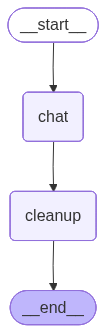

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "t1"}}

In [10]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='a752336a-afe0-4950-9f39-2881c36c6d4e'),
  AIMessage(content="LangChain is an open-source framework designed to simplify and streamline the development of applications that use large language models (LLMs). It provides a structured way to build applications that incorporate LLMs for a variety of tasks such as natural language processing, question answering, summarization, and more. Here are some key features and components of LangChain:\n\n### Key Features\n\n1. **Modular Components**: LangChain consists of several modular components that can be combined to create various applications. This includes components for interacting with language models, managing prompts, and integrating with other data sources.\n\n2. **Prompt Management**: LangChain allows developers to manage prompts efficiently, which is crucial since the input to LLMs (like OpenAI's GPT series) significantly influences t

On top you see so many 7 user query and 7 AI message i.e, 14 total mesages but we had coded| that if the messages are more than 10, then remove 6, so we are only storing 14-6 = 8 messages. You can see below.

In [11]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
